In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json, os
from scipy import stats
import pandas as pd
from tools import get_as_results, get_parallel_results, to_table, combine_algorithm_selection_score, compute_mcnemar, get_as_accuracy_results, compare_as_accuracy_results
from sklearn.metrics import accuracy_score

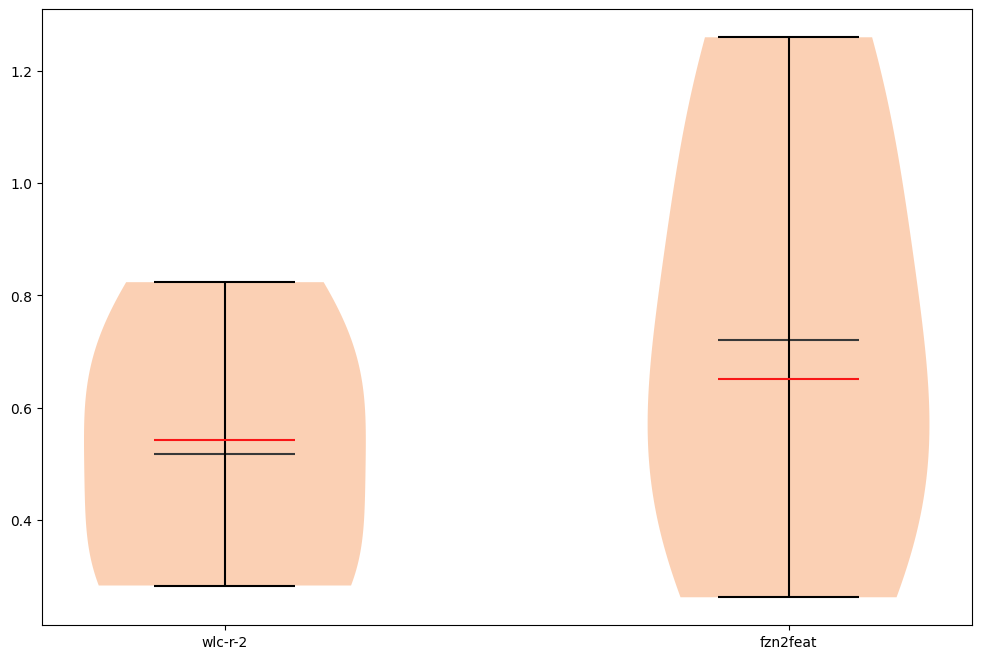

In [6]:
# as_results = {}
r = {}
for file in ['0', '1', '2', '3', '4', '0f', '1f', '2f', '3f', '4f']:
    # if not file.startswith("as_"):
    #     continue
    fold = file.replace('f', '')
    feature_names = 'wlc-r-2' if not 'f' in file else 'fzn2feat'
    with open(file) as f:
        content = json.load(f)
    if feature_names not in r:
        r[feature_names] = []
    r[feature_names].append((content['clf_time'] - content['clf_vbs']) / (content['cp-sat_time'] - content['clf_vbs']))

plt.figure(figsize=(12,8))
violin_parts = plt.violinplot(r.values(), showmeans=True, showmedians=True)

for pc in violin_parts['bodies']:
    pc.set_facecolor('#f46607')
violin_parts['cbars'].set_color('black')
violin_parts['cmins'].set_color('black')
violin_parts['cmaxes'].set_color('black')
violin_parts['cmaxes'].set_color('black')
violin_parts['cmedians'].set_color('#f91616')
violin_parts['cmeans'].set_color('#383838')

plt.xticks([i for i in range(1, len(r.keys())+1)], r.keys())
plt.show()

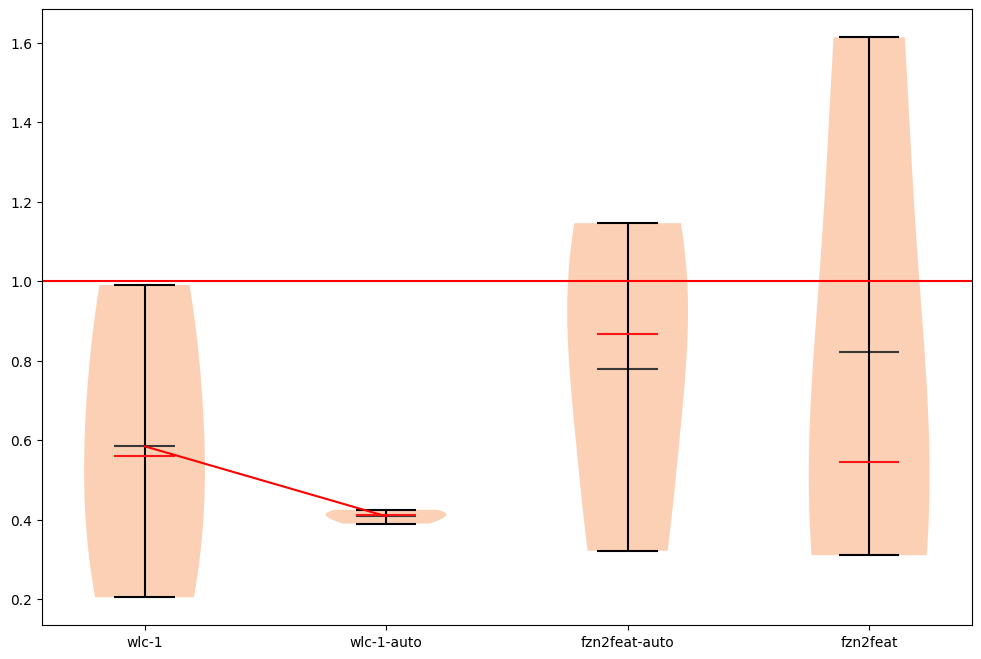

In [6]:
plt.figure(figsize=(12,8))
violin_parts = plt.violinplot(as_results_plot.values(), showmeans=True, showmedians=True)

for pc in violin_parts['bodies']:
    pc.set_facecolor('#f46607')
violin_parts['cbars'].set_color('black')
violin_parts['cmins'].set_color('black')
violin_parts['cmaxes'].set_color('black')
violin_parts['cmaxes'].set_color('black')
violin_parts['cmedians'].set_color('#f91616')
violin_parts['cmeans'].set_color('#383838')

plt.axhline(y=1, c='red')

plt.plot([i for i in range(1, len([np.mean(v) for k, v in as_results_plot.items() if 'fzn2feat' not in k])+1)], [np.mean(v) for k, v in as_results_plot.items() if 'fzn2feat' not in k], c='red')

plt.xticks([i for i in range(1, len(as_results_plot.keys())+1)], as_results_plot.keys())
plt.show()

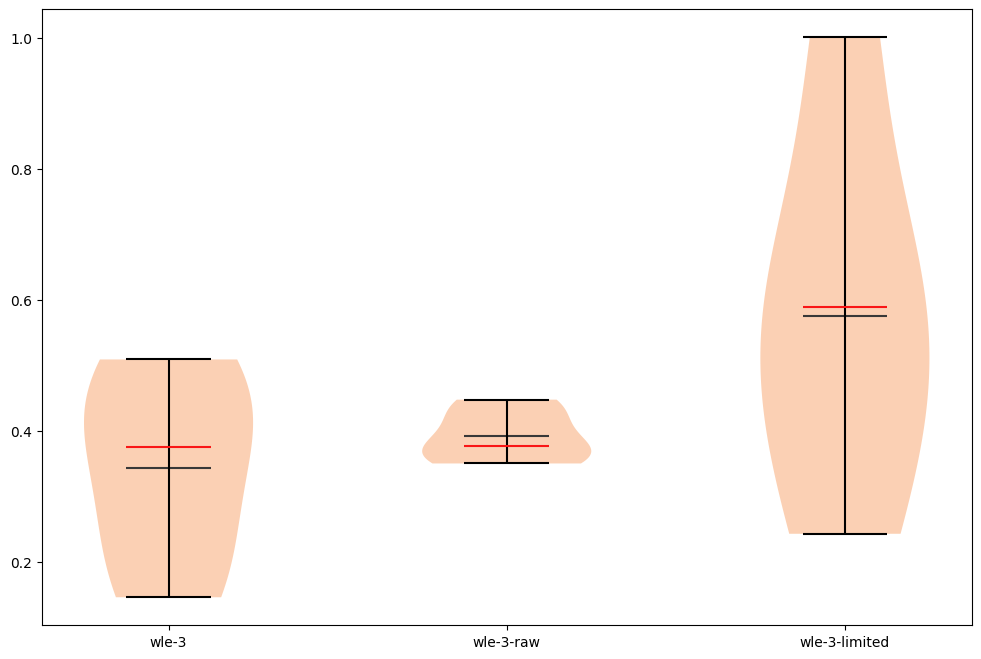

In [ ]:
plt.figure(figsize=(12,8))
comparisons = {k:v for k,v in sorted(as_results.items(), key=lambda x: order[x[0]]) if 'wle-3' in k}


violin_parts = plt.violinplot(comparisons.values(), showmeans=True, showmedians=True)

for pc in violin_parts['bodies']:
    pc.set_facecolor('#f46607')
violin_parts['cbars'].set_color('black')
violin_parts['cmins'].set_color('black')
violin_parts['cmaxes'].set_color('black')
violin_parts['cmaxes'].set_color('black')
violin_parts['cmedians'].set_color('#f91616')
violin_parts['cmeans'].set_color('#383838')

plt.xticks([i for i in range(1, len(comparisons.keys())+1)], comparisons.keys())
plt.show()

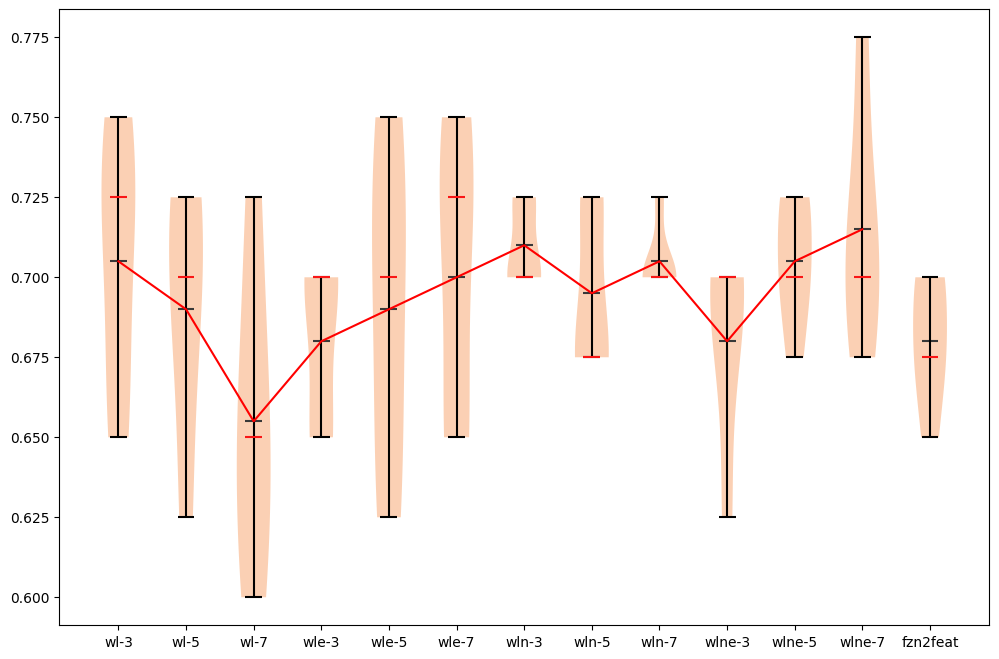

In [14]:
accuracy_result = {}
for file in os.listdir(RESULT_FOLDER):
    if not file.startswith("as_"):
        continue
    name_split = file.replace("as_", "").replace("-forest", "").split("-")
    fold = name_split[-1]
    feature_names = "-".join(name_split[:-1])
    with open(os.path.join(RESULT_FOLDER, file)) as f:
        content = json.load(f)
    if feature_names not in accuracy_result:
        accuracy_result[feature_names] = []
    accuracy_result[feature_names].append(content['accuracy'])

order = {
    'wl-3' : 0,
    'wl-5' : 1,
    'wl-7' : 2,

    'wle-3' : 3,
    'wle-3-raw' : 4,
    'wle-3-limited' : 5,
    'wle-5' : 6,
    'wle-7' : 7,

    'wln-3' : 8,
    'wln-5' : 9,
    'wln-7' : 10,

    'wlne-3' : 11,
    'wlne-5' : 12,
    'wlne-7' : 13,

    'fzn2feat':14
}
accuracy_result_plot = {k:v for k,v in sorted(accuracy_result.items(), key=lambda x: order[x[0]]) if not 'raw' in k and not 'limited' in k}

plt.figure(figsize=(12,8))
violin_parts = plt.violinplot(accuracy_result_plot.values(), showmeans=True, showmedians=True)

for pc in violin_parts['bodies']:
    pc.set_facecolor('#f46607')
violin_parts['cbars'].set_color('black')
violin_parts['cmins'].set_color('black')
violin_parts['cmaxes'].set_color('black')
violin_parts['cmaxes'].set_color('black')
violin_parts['cmedians'].set_color('#f91616')
violin_parts['cmeans'].set_color('#383838')

plt.plot([i for i in range(1, len(accuracy_result_plot.keys()))], [np.mean(v) for k, v in accuracy_result_plot.items() if k != 'fzn2feat'], c='red')

plt.xticks([i for i in range(1, len(accuracy_result_plot.keys())+1)], accuracy_result_plot.keys())
plt.show()

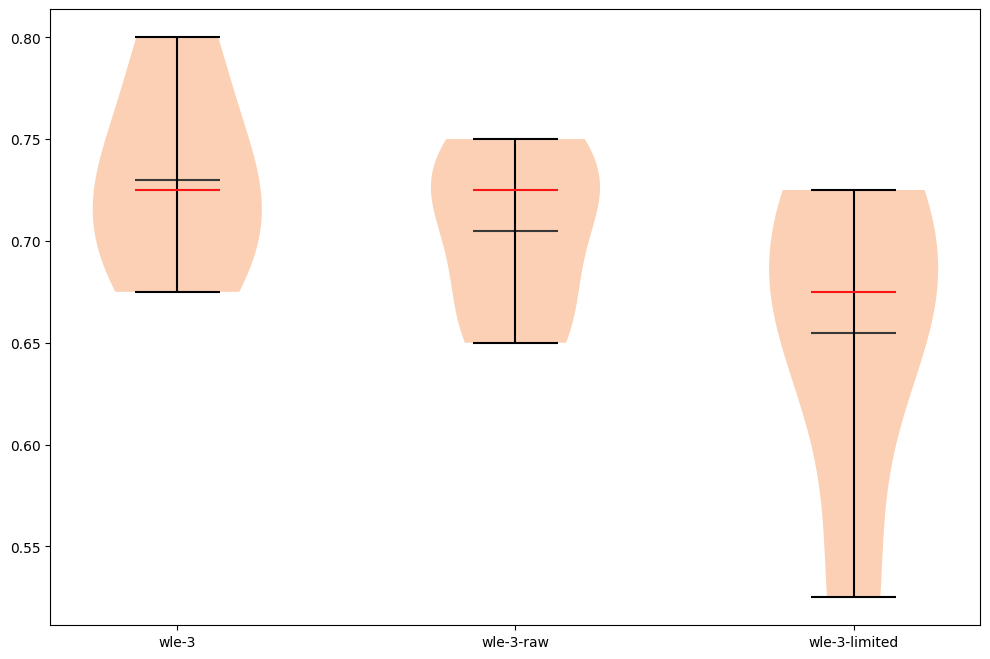

In [22]:
plt.figure(figsize=(12,8))
comparisons_accuracy = {k:v for k,v in sorted(accuracy_result.items(), key=lambda x: order[x[0]]) if 'wle-3' in k}


violin_parts = plt.violinplot(comparisons_accuracy.values(), showmeans=True, showmedians=True)

for pc in violin_parts['bodies']:
    pc.set_facecolor('#f46607')
violin_parts['cbars'].set_color('black')
violin_parts['cmins'].set_color('black')
violin_parts['cmaxes'].set_color('black')
violin_parts['cmaxes'].set_color('black')
violin_parts['cmedians'].set_color('#f91616')
violin_parts['cmeans'].set_color('#383838')

plt.xticks([i for i in range(1, len(comparisons_accuracy.keys())+1)], comparisons_accuracy.keys())
plt.show()

In [2]:
total = {
    'wl-1': {'scores': {'svc': [], 'forest': [], 'nn': []}, 'accuracy': {'svc': [], 'forest': [], 'nn': []}, 'par': {'svc': [], 'forest': [], 'nn': []}},
    'wl-2': {'scores': {'svc': [], 'forest': [], 'nn': []}, 'accuracy': {'svc': [], 'forest': [], 'nn': []}, 'par': {'svc': [], 'forest': [], 'nn': []}},

    'wle-1': {'scores': {'svc': [], 'forest': [], 'nn': []}, 'accuracy': {'svc': [], 'forest': [], 'nn': []}, 'par': {'svc': [], 'forest': [], 'nn': []}},
    'wle-2': {'scores': {'svc': [], 'forest': [], 'nn': []}, 'accuracy': {'svc': [], 'forest': [], 'nn': []}, 'par': {'svc': [], 'forest': [], 'nn': []}},

    'wln-1': {'scores': {'svc': [], 'forest': [], 'nn': []}, 'accuracy': {'svc': [], 'forest': [], 'nn': []}, 'par': {'svc': [], 'forest': [], 'nn': []}},
    'wln-2': {'scores': {'svc': [], 'forest': [], 'nn': []}, 'accuracy': {'svc': [], 'forest': [], 'nn': []}, 'par': {'svc': [], 'forest': [], 'nn': []}},

    'wlne-1': {'scores': {'svc': [], 'forest': [], 'nn': []}, 'accuracy': {'svc': [], 'forest': [], 'nn': []}, 'par': {'svc': [], 'forest': [], 'nn': []}},
    'wlne-2': {'scores': {'svc': [], 'forest': [], 'nn': []}, 'accuracy': {'svc': [], 'forest': [], 'nn': []}, 'par': {'svc': [], 'forest': [], 'nn': []}},

    'wlc-1': {'scores': {'svc': [], 'forest': [], 'nn': []}, 'accuracy': {'svc': [], 'forest': [], 'nn': []}, 'par': {'svc': [], 'forest': [], 'nn': []}},
    'wlc-2': {'scores': {'svc': [], 'forest': [], 'nn': []}, 'accuracy': {'svc': [], 'forest': [], 'nn': []}, 'par': {'svc': [], 'forest': [], 'nn': []}},

    'wlce-1': {'scores': {'svc': [], 'forest': [], 'nn': []}, 'accuracy': {'svc': [], 'forest': [], 'nn': []}, 'par': {'svc': [], 'forest': [], 'nn': []}},
    'wlce-2': {'scores': {'svc': [], 'forest': [], 'nn': []}, 'accuracy': {'svc': [], 'forest': [], 'nn': []}, 'par': {'svc': [], 'forest': [], 'nn': []}},

    'fzn2feat': {'scores': {'svc': [], 'forest': [], 'nn': []}, 'accuracy': {'svc': [], 'forest': [], 'nn': []}, 'par': {'svc': [], 'forest': [], 'nn': []}},
}

score_folder = '../data/as-scores-results/'
for model in ['svc', 'forest', 'nn']:
    folder = score_folder + model + '-scores/'
    for file in os.listdir(folder):
        assert 'json' in file
        mn = model if model != 'forest' else 'rnd-forest'
        feature_set = file.replace('as_', '').split(f'-{mn}-')[0]
        total[feature_set]['scores'][model].append(file)
from pprint import pp
for feature_set in total.keys():
    for model in ['svc', 'forest', 'nn']:
        assert len(total[feature_set]['scores'][model]) == len(set(total[feature_set]['scores'][model]))
        total[feature_set]['scores'][model] = len(total[feature_set]['scores'][model])

accuracy_folder = '../data/as-accuracy-results/'
for model in ['svc', 'forest', 'nn']:
    folder = accuracy_folder + model + '-scores/'
    for file in os.listdir(folder):
        assert 'json' in file
        mn = model if model != 'forest' else 'rnd-forest'
        feature_set = file.replace('as-accuracy_', '').split(f'-{mn}-')[0]
        total[feature_set]['accuracy'][model].append(file)
from pprint import pp
for feature_set in total.keys():
    for model in ['svc', 'forest', 'nn']:
        assert len(total[feature_set]['accuracy'][model]) == len(set(total[feature_set]['accuracy'][model]))
        total[feature_set]['accuracy'][model] = len(total[feature_set]['accuracy'][model])

parallel_folder = '../data/parallelise-results/'
for model in ['svc', 'forest', 'nn']:
    folder = parallel_folder + model + '-parallelise/'
    for file in os.listdir(folder):
        assert 'json' in file
        mn = model if model != 'forest' else 'rnd-forest'
        feature_set = file.replace('par_', '').split(f'-{mn}-')[0]
        total[feature_set]['par'][model].append(file)
from pprint import pp
for feature_set in total.keys():
    for model in ['svc', 'forest', 'nn']:
        assert len(total[feature_set]['par'][model]) == len(set(total[feature_set]['par'][model]))
        total[feature_set]['par'][model] = len(total[feature_set]['par'][model])

total_missing = 0
for feature_set in total.keys():
    print("===========================================")
    total_missing += (50 - total[feature_set]["scores"]["svc"]) + (50 - total[feature_set]["scores"]["forest"]) + (50 - total[feature_set]["scores"]["nn"]) \
                   + (50 - total[feature_set]["accuracy"]["svc"]) + (50 - total[feature_set]["accuracy"]["forest"]) + (50 - total[feature_set]["accuracy"]["nn"]) \
                   + (50 - total[feature_set]["par"]["svc"]) + (50 - total[feature_set]["par"]["forest"]) + (50 - total[feature_set]["par"]["nn"])
    print(f'''{feature_set}: 
scores: ({50 - total[feature_set]["scores"]["svc"]}, {50 - total[feature_set]["scores"]["forest"]}, {50 - total[feature_set]["scores"]["nn"]})
accuracy: ({50 - total[feature_set]["accuracy"]["svc"]}, {50 - total[feature_set]["accuracy"]["forest"]}, {50 - total[feature_set]["accuracy"]["nn"]})
parallel: ({50 - total[feature_set]["par"]["svc"]}, {50 - total[feature_set]["par"]["forest"]}, {50 - total[feature_set]["par"]["nn"]})''')

print("total missing experiments:", total_missing)

wl-1: 
scores: (0, 50, 50)
accuracy: (50, 50, 50)
parallel: (25, 50, 50)
wl-2: 
scores: (21, 50, 50)
accuracy: (50, 50, 50)
parallel: (25, 50, 50)
wle-1: 
scores: (0, 2, 50)
accuracy: (50, 50, 50)
parallel: (25, 50, 50)
wle-2: 
scores: (0, 22, 50)
accuracy: (50, 50, 50)
parallel: (25, 50, 50)
wln-1: 
scores: (0, 15, 50)
accuracy: (25, 50, 50)
parallel: (25, 25, 48)
wln-2: 
scores: (0, 30, 50)
accuracy: (50, 50, 50)
parallel: (25, 50, 50)
wlne-1: 
scores: (25, 50, 50)
accuracy: (50, 50, 50)
parallel: (25, 25, 48)
wlne-2: 
scores: (50, 50, 50)
accuracy: (50, 50, 50)
parallel: (25, 25, 50)
wlc-1: 
scores: (0, 0, 0)
accuracy: (0, 0, 0)
parallel: (0, 4, 25)
wlc-2: 
scores: (0, 0, 0)
accuracy: (0, 0, 0)
parallel: (0, 19, 25)
wlce-1: 
scores: (50, 50, 50)
accuracy: (50, 50, 50)
parallel: (25, 25, 50)
wlce-2: 
scores: (50, 50, 50)
accuracy: (50, 50, 50)
parallel: (50, 25, 50)
fzn2feat: 
scores: (0, 0, 0)
accuracy: (0, 0, 0)
parallel: (0, 0, 0)
total missing experiments: 3759


# Borda-count Scores

In [4]:
folder = '../data/as-scores-results/svc-scores'
dataset = '../data/algorithm_selection_dataset_score.csv'
print(folder, ':')
res_svc = get_as_results(folder)
res_svc['combined-fzn2feat'] = {}
res_svc['combined-wlc'] = {}
for seed in ["7", '12', "42", "72", "123", "156", "197", "205", "224", "242"]:
    for fold in range(5):
        s1 = f'../data/as-scores-results/svc-scores/as_wlc-1-svc-{fold}-{seed}.json'
        s2 = f'../data/as-scores-results/svc-scores/as_wlc-2-svc-{fold}-{seed}.json'
        s3 = f'../data/as-scores-results/forest-scores/as_fzn2feat-rnd-forest-{fold}-{seed}.json'
        res_svc['combined-fzn2feat'][f'{fold}-{seed}'] = combine_algorithm_selection_score(s1, s2, dataset, s3)
        res_svc['combined-wlc'][f'{fold}-{seed}'] = combine_algorithm_selection_score(s1, s2, dataset)
fzn2feat = list(res_svc['fzn2feat'].values())
t_stat, p_value = stats.wilcoxon(list(res_svc['wlc-1'].values()), fzn2feat)
print("wlc-1:", p_value)
t_stat, p_value = stats.wilcoxon(list(res_svc['wlc-2'].values()), fzn2feat)
print("wlc-2:", p_value)
display(to_table(res_svc))

../data/as-scores-results/svc-scores :
wlc-1: 0.002996250182501825
wlc-2: 0.01958777690517799


,Mean,Median,Std,Max,Min,Worse_sbs
fzn2feat,0.403998,0.393410,0.144663,0.695461,0.060593,0
wl-1,0.197307,0.221347,0.151943,0.493598,-0.294077,7
wle-1,0.128665,0.152632,0.246157,0.534528,-0.919572,11
wle-2,0.104841,0.139820,0.254606,0.470660,-0.696799,12
wln-1,0.210201,0.244648,0.188278,0.499440,-0.336539,7
wln-2,0.282667,0.276099,0.149708,0.586188,-0.102522,2
wlc-1,0.484961,0.506030,0.160183,0.743272,0.070355,0
wlc-2,0.472466,0.503657,0.196363,0.743609,-0.363986,1
combined-fzn2feat,0.522545,0.556114,0.152831,0.793287,0.109003,0
combined-wlc,0.494417,0.533252,0.153041,0.743272,0.154594,0


In [ ]:
folder = '../data/as-scores-results/forest-scores'
print(folder, ':')
res_forest = get_as_results(folder)
fzn2feat = list(res_forest['fzn2feat'].values())
t_stat, p_value = stats.wilcoxon(list(res_forest['wlc-1'].values()), fzn2feat)
print('wlc-1:', p_value)
t_stat, p_value = stats.wilcoxon(list(res_forest['wlc-2'].values()), fzn2feat)
print('wlc-2:', p_value)
display(to_table(res_forest))

../data/as-scores-results/forest-scores :
wlc-1: 0.5526669770606443
wlc-2: 0.6736344940466168


,Mean,Median,Std,Max,Min,Worse_sbs
fzn2feat,0.453126,0.469145,0.169899,0.793287,-0.085975,1
wle-1,0.349009,0.357495,0.168256,0.645770,-0.173245,1
wle-2,0.416928,0.425804,0.118646,0.635813,0.167517,0
wln-1,0.422205,0.416575,0.125833,0.633095,0.042360,0
wlc-1,0.442881,0.443803,0.141967,0.790252,0.172934,0
wlc-2,0.449713,0.443803,0.137703,0.715554,0.106153,0
wln-2,0.474478,0.470259,0.112965,0.638599,0.211823,0


In [ ]:
folder = '../data/as-scores-results/nn-scores'
print(folder, ':')
res = get_as_results(folder)
fzn2feat = list(res['fzn2feat'].values())
t_stat, p_value = stats.wilcoxon(list(res['wlc-1'].values()), fzn2feat)
print("wlc-1:", p_value)
t_stat, p_value = stats.wilcoxon(list(res['wlc-2'].values()), fzn2feat)
print("wlc-2:", p_value)
display(to_table(res))

../data/as-scores-results/nn-scores :
wlc-1: 0.054216182330456775
wlc-2: 0.03996834652842374


,Mean,Median,Std,Max,Min,Worse_sbs
fzn2feat,0.320309,0.349813,0.213622,0.743848,-0.252822,3
wlc-1,0.399279,0.412857,0.133137,0.720193,0.078721,0
wlc-2,0.392549,0.409654,0.142383,0.637640,0.033634,0


# Algorithm Selection Accuracy Scores

In [3]:
compare_as_accuracy_results(('wlc-1', 'svc'),('fzn2feat', 'forest'), '../data/as-accuracy-results')

(0.6948096885813149, 0.6667820069204152, 0.0006394217955246711)

In [11]:
folder = '../data/as-accuracy-results/svc-scores'
print(folder, ':')
res = get_as_accuracy_results(folder)
fzn2feat = list(res['fzn2feat'].values())
t_stat, p_value = stats.wilcoxon(list(res['wlc-1'].values()), fzn2feat)
print('wlc-1:', p_value)
t_stat, p_value = stats.wilcoxon(list(res['wlc-2'].values()), fzn2feat)
print('wlc-2:', p_value)
to_table(res, False)

../data/as-accuracy-results/svc-scores :
wlc-1: 1.6027711723756744e-05
wlc-2: 6.730663031992932e-05


,Mean,Median,Std,Max,Min
fzn2feat,0.628796,0.634755,0.058112,0.741379,0.517241
wlc-1,0.694737,0.681034,0.069942,0.879310,0.543860
wlc-2,0.686866,0.689655,0.066473,0.810345,0.551724
wln-1,0.582734,0.586207,0.058052,0.724138,0.465517


In [12]:
folder = '../data/as-accuracy-results/forest-scores'
print(folder, ':')
res = get_as_accuracy_results(folder)
fzn2feat = list(res['fzn2feat'].values())
t_stat, p_value = stats.wilcoxon(list(res['wlc-1'].values()), fzn2feat)
print('wlc-1:', p_value)
t_stat, p_value = stats.wilcoxon(list(res['wlc-2'].values()), fzn2feat)
print('wlc-2:', p_value)
to_table(res, False)

../data/as-accuracy-results/forest-scores :
wlc-1: 0.7950904404103775
wlc-2: 0.6392932003541856


,Mean,Median,Std,Max,Min
fzn2feat,0.666836,0.672414,0.053620,0.758621,0.517241
wlc-1,0.666437,0.652148,0.055553,0.775862,0.568966
wlc-2,0.665741,0.655172,0.060089,0.827586,0.534483


In [14]:
folder = '../data/as-accuracy-results/nn-scores'
print(folder, ':')
res = get_as_accuracy_results(folder)
fzn2feat = list(res['fzn2feat'].values())
t_stat, p_value = stats.wilcoxon(list(res['wlc-1'].values()), fzn2feat)
print('wlc-1:', p_value)
t_stat, p_value = stats.wilcoxon(list(res['wlc-2'].values()), fzn2feat)
print('wlc-2:', p_value)
to_table(res, False)

../data/as-accuracy-results/nn-scores :
wlc-1: 0.8035336609877415
wlc-2: 0.7961309923635564


,Mean,Median,Std,Max,Min
fzn2feat,0.624598,0.620690,0.058175,0.775862,0.465517
wlc-1,0.628772,0.620690,0.058302,0.758621,0.500000
wlc-2,0.621440,0.626134,0.055993,0.741379,0.500000


# Parallel Predictions

In [5]:
from sklearn.metrics import accuracy_score
def get_parallel_results(result_folder):
    as_results = {}
    for file in os.listdir(result_folder):
        if not file.startswith("par_"):
            continue
        # if not "123" in file:
        #     continue
        if 'forest' in file:
            name_split = file.replace("par_", "").replace("-rnd-forest", "").replace("-forest", "").replace(".json", "").split("-")
        elif 'svc' in file:
            name_split = file.replace("par_", "").replace("-svc", "").replace(".json", "").split("-")
        elif 'f-knn' in file:
            name_split = file.replace("par_", "").replace("-f-knn", "").replace(".json", "").split("-")
        elif 'knn' in file:
            name_split = file.replace("par_", "").replace("-knn", "").replace(".json", "").split("-")
        elif 'nn' in file:
            name_split = file.replace("par_", "").replace("-nn", "").replace(".json", "").split("-")
        fold = "-".join(name_split[-2:])
        feature_names = "-".join(name_split[:-2])
        # print(name_split, fold, feature_names)
        with open(os.path.join(result_folder, file)) as f:
            content = json.load(f)
        if feature_names not in as_results:
            as_results[feature_names] = {}
        as_results[feature_names][fold] = content['accuracy']
    feature_names = 'majority_classifier'
    as_results[feature_names] = {}
    for file in os.listdir(result_folder):
        if not file.startswith("par_"):
            continue
        if not "fzn2feat" in file:
            continue
        if 'forest' in file:
            name_split = file.replace("par_", "").replace("-rnd-forest", "").replace("-forest", "").replace(".json", "").split("-")
        elif 'svc' in file:
            name_split = file.replace("par_", "").replace("-svc", "").replace(".json", "").split("-")
        elif 'f-knn' in file:
            name_split = file.replace("par_", "").replace("-f-knn", "").replace(".json", "").split("-")
        elif 'knn' in file:
            name_split = file.replace("par_", "").replace("-knn", "").replace(".json", "").split("-")
        elif 'nn' in file:
            name_split = file.replace("par_", "").replace("-nn", "").replace(".json", "").split("-")
        fold = "-".join(name_split[-2:])
        with open(os.path.join(result_folder, file)) as f:
            content = json.load(f)
        trues = [v['true'] for v in content['predictions'].values()]
        pred = [1 for _ in content['predictions'].values()]
        as_results[feature_names][fold] = accuracy_score(trues, pred)
    return {k:v for k,v in sorted(as_results.items(), key= lambda x: (order[x[0].replace('-max', '').replace('-min', '')], 0 if '-min' in x[0] else 1))}

In [8]:
for folder in ['data/parallelise-results/svc-parallelise']:
    print(folder, ':')
    res = get_parallel_results(folder)
    fzn2feat = list(res['fzn2feat'].values())
    wlc1_svc = list(res['wlc-1'].values())
    t_stat, p_value = stats.wilcoxon(wlc1_svc, fzn2feat)
    print(p_value)
    display(to_table(res, key=str))

data/parallelise-results/svc-parallelise :
0.8751069802067012


,0-12,0-123,0-42,0-7,0-72,1-12,1-123,1-42,1-7,1-72,...,4-7,4-72,wins,avg_win_margin,Worse_sbs,Mean,Median,Std,Max,Min
fzn2feat,0.633333,0.683333,0.516667,0.683333,0.683333,0.716667,0.633333,0.583333,0.683333,0.650000,...,0.694915,0.593220,6,0.030056,0,0.634124,0.650000,0.061594,0.716667,0.483333
wl-1,0.616667,0.550000,0.500000,0.550000,0.666667,0.550000,0.500000,0.633333,0.550000,0.633333,...,0.559322,0.593220,2,0.000000,0,0.564678,0.559322,0.069748,0.683333,0.416667
wl-2,0.533333,0.600000,0.483333,0.483333,0.583333,0.500000,0.716667,0.666667,0.583333,0.533333,...,0.593220,0.661017,4,0.033427,0,0.598113,0.593220,0.071812,0.783333,0.483333
wle-1,0.350000,0.583333,0.483333,0.633333,0.600000,0.650000,0.666667,0.566667,0.483333,0.533333,...,0.661017,0.644068,0,0.000000,0,0.556531,0.566667,0.073468,0.666667,0.350000
wle-2,0.566667,0.533333,0.533333,0.516667,0.733333,0.650000,0.583333,0.533333,0.483333,0.516667,...,0.508475,0.491525,0,0.000000,0,0.561141,0.533333,0.069650,0.733333,0.450000
wln-1,0.683333,0.700000,0.566667,0.716667,0.666667,0.616667,0.666667,0.566667,0.616667,0.650000,...,0.610169,0.593220,7,0.016667,0,0.637446,0.633333,0.049381,0.716667,0.550000
wln-2,0.533333,0.683333,0.533333,0.650000,0.716667,0.583333,0.666667,0.550000,0.666667,0.666667,...,0.576271,0.627119,2,0.016667,0,0.608610,0.627119,0.067269,0.716667,0.500000
wlne-1,0.683333,0.683333,0.616667,0.700000,0.700000,0.616667,0.633333,0.566667,0.650000,0.650000,...,0.610169,0.593220,5,0.000000,0,0.641446,0.633333,0.042530,0.711864,0.550000
wlne-2,0.533333,0.683333,0.533333,0.650000,0.733333,0.666667,0.516667,0.533333,0.666667,0.650000,...,0.610169,0.627119,1,0.000000,0,0.608667,0.627119,0.066007,0.733333,0.516667
wlc-1,0.650000,0.600000,0.616667,0.616667,0.800000,0.683333,0.666667,0.633333,0.633333,0.666667,...,0.661017,0.542373,5,0.000000,0,0.634011,0.633333,0.071514,0.800000,0.500000


In [23]:
for folder in ['nn-parallelise']:
    print(folder, ':')
    res = get_parallel_results(folder)
    fzn2feat_nn = list(res['fzn2feat'].values())
    wlc1 = list(res['wlc-1'].values())
    t_stat, p_value = stats.wilcoxon(wlc1, fzn2feat_nn)
    print(p_value)
    display(to_table(res, key=str))

nn-parallelise :
0.41112421879697114


,0-12,0-123,0-42,0-7,0-72,1-12,1-123,1-42,1-7,1-72,...,4-7,4-72,wins,avg_win_margin,Worse_sbs,Mean,Median,Std,Max,Min
fzn2feat,0.716667,0.683333,0.683333,0.650000,0.800000,0.700000,0.750000,0.533333,0.683333,0.583333,...,0.677966,0.661017,14,0.035003,0,0.666791,0.677966,0.056545,0.800000,0.533333
wlc-1,0.633333,0.666667,0.616667,0.666667,0.783333,0.716667,0.716667,0.683333,0.616667,0.600000,...,0.661017,0.576271,6,0.016667,0,0.656768,0.661017,0.051928,0.783333,0.576271
wlc-2,0.633333,0.700000,0.633333,0.633333,0.783333,0.633333,0.683333,0.666667,0.666667,0.600000,...,0.661017,0.576271,10,0.036347,0,0.660169,0.661017,0.049773,0.783333,0.566667
majority_classifier,0.516667,0.516667,0.516667,0.516667,0.516667,0.516667,0.516667,0.516667,0.516667,0.516667,...,0.525424,0.525424,0,0.000000,0,0.518418,0.516667,0.003575,0.525424,0.516667
wln-1,NaN,NaN,NaN,0.650000,NaN,NaN,NaN,NaN,0.600000,NaN,...,NaN,NaN,0,0.000000,0,0.625000,0.625000,0.035355,0.650000,0.600000
wlne-1,NaN,NaN,NaN,0.666667,NaN,NaN,NaN,NaN,0.666667,NaN,...,NaN,NaN,1,0.000000,0,0.666667,0.666667,0.000000,0.666667,0.666667


In [153]:
for folder in ['data/parallelise-results/forest-parallelise']:
    print(folder, ':')
    res = get_parallel_results(folder)
    fzn2feat = list(res['fzn2feat'].values())
    wlc1_forest = list(res['wlc-1'].values())
    t_stat, p_value = stats.wilcoxon(wlc1_forest, fzn2feat)
    print(p_value)
    display(to_table(res, key=str))

data/parallelise-results/forest-parallelise :
0.00016230344772338867


,0-12,0-123,0-42,0-7,0-72,1-12,1-123,1-42,1-7,1-72,...,4-7,4-72,wins,avg_win_margin,Worse_sbs,Mean,Median,Std,Max,Min
fzn2feat,0.500000,0.616667,0.683333,0.666667,0.533333,0.666667,0.533333,0.483333,0.533333,0.650000,...,0.576271,0.559322,4,0.016667,0,0.568588,0.533333,0.085147,0.716667,0.383333
wln-1,0.650000,0.616667,0.666667,0.700000,0.650000,0.666667,0.700000,0.650000,0.583333,0.600000,...,0.711864,0.559322,6,0.033522,0,0.650881,0.650000,0.049771,0.745763,0.550000
wlne-1,0.600000,0.583333,0.650000,0.666667,0.800000,0.733333,0.716667,0.600000,0.683333,0.616667,...,0.694915,0.576271,5,0.033333,0,0.661492,0.666667,0.052948,0.800000,0.576271
wlne-2,0.650000,0.583333,0.650000,0.666667,0.733333,0.683333,0.700000,0.683333,0.700000,0.616667,...,0.745763,0.576271,5,0.025282,0,0.663571,0.666667,0.044997,0.745763,0.576271
wlc-1,0.566667,0.616667,0.633333,0.666667,0.700000,0.633333,0.633333,0.733333,0.616667,0.600000,...,0.694915,0.593220,4,0.000000,0,0.651469,0.633333,0.047681,0.766667,0.566667
wlc-2,0.583333,0.616667,0.500000,0.650000,0.766667,0.633333,0.733333,0.616667,0.633333,0.633333,...,0.711864,0.593220,4,0.016667,0,0.645412,0.650000,0.063243,0.766667,0.500000
wlce-1,0.616667,0.616667,0.616667,0.666667,0.666667,0.650000,0.616667,0.750000,0.633333,0.633333,...,0.694915,0.610169,6,0.050141,0,0.658893,0.650000,0.053749,0.783333,0.566667
wlce-2,0.633333,0.600000,0.616667,0.600000,0.766667,0.700000,0.716667,0.750000,0.666667,0.633333,...,0.508475,0.610169,6,0.025000,0,0.648689,0.633333,0.062817,0.766667,0.508475
majority_classifier,0.516667,0.516667,0.516667,0.516667,0.516667,0.516667,0.516667,0.516667,0.516667,0.516667,...,0.525424,0.525424,0,0.000000,0,0.518418,0.516667,0.003575,0.525424,0.516667


In [8]:
for folder in ['data/as-accuracy-results/forest-scores/']:
    print(folder, ':')
    res = get_parallel_results(folder)
    fzn2feat = list(res['fzn2feat'].values())
    # wlc1_svc = list(res['wlc-1'].values())
    # t_stat, p_value = stats.ttest_rel(wlc1_svc, fzn2feat)
    # print(p_value)
    display(to_table(res, str))

data/as-accuracy-results/forest-scores/ :


,0-12,0-123,0-156,0-197,0-205,0-224,0-242,0-42,0-7,0-72,...,4-7,4-72,wins,avg_win_margin,Worse_sbs,Mean,Median,Std,Max,Min
fzn2feat,0.672414,0.637931,0.741379,0.586207,0.655172,0.706897,0.724138,0.655172,0.689655,0.620690,...,0.684211,0.649123,32,0.036408,0,0.666836,0.672414,0.053620,0.758621,0.517241
wlc-1,0.655172,0.637931,NaN,0.689655,0.655172,0.706897,NaN,0.620690,0.568966,0.775862,...,0.771930,0.631579,18,0.041958,0,0.663982,0.649123,0.056797,0.775862,0.568966
wlc-2,0.672414,0.603448,NaN,0.655172,0.637931,0.637931,NaN,0.655172,0.637931,0.706897,...,0.771930,0.614035,17,0.041379,0,0.663967,0.655172,0.059597,0.827586,0.534483


In [53]:
for folder in ['data/as-accuracy-results/nn-scores/']:
    print(folder, ':')
    res = get_parallel_results(folder)
    # fzn2feat = list(res['fzn2feat'].values())
    # wlc1_svc = list(res['wlc-1'].values())
    # t_stat, p_value = stats.ttest_rel(wlc1_svc, fzn2feat)
    # print(p_value)
    display(to_table(res, str))

data/as-accuracy-results/nn-scores/ :


,0-12,0-123,0-154,0-197,0-205,0-224,0-236,0-42,0-7,0-72,...,4-7,4-72,wins,avg_win_margin,Worse_sbs,Mean,Median,Std,Max,Min
fzn2feat,0.689655,0.603448,NaN,NaN,NaN,NaN,NaN,0.672414,0.603448,0.655172,...,0.701754,0.561404,11,0.034584,0,0.629074,0.637931,0.062830,0.741379,0.465517
wlc-1,0.655172,0.620690,0.568966,0.620690,0.586207,0.689655,0.655172,0.568966,0.620690,0.758621,...,0.684211,0.526316,29,0.054043,0,0.631210,0.629310,0.054919,0.758621,0.500000
wlc-2,0.655172,0.603448,0.637931,0.534483,0.586207,0.568966,0.620690,0.603448,0.637931,0.637931,...,0.684211,0.596491,17,0.031513,0,0.615977,0.620690,0.050261,0.724138,0.500000


# Feature Extraction Cost

In [10]:
wlc1 = pd.read_csv('wlc1_extraction.csv')
wlc2 = pd.read_csv('wlc2_extraction.csv')
fzn2feat = pd.read_csv('fzn2feat_extraction.csv')

In [11]:
wlc1['wlc1_time'] = wlc1['time']
wlc1 = wlc1.drop(columns=['time'])
wlc2['wlc2_time'] = wlc2['time']
wlc2 = wlc2.drop(columns=['time'])
fzn2feat['fzn2feat_time'] = fzn2feat['time']
fzn2feat = fzn2feat.drop(columns=['time'])

In [12]:
merged = wlc1.merge(wlc2, on='name').merge(fzn2feat, on='name')
merged

,name,wlc1_time,wlc2_time,fzn2feat_time
0,portal-sep-small_3,0.102439,0.102300,0.022730
1,portal-sep-random_10_9_10,0.041639,0.039833,0.011155
2,portal-sep-random_20_9_100,0.654443,0.680940,0.183309
3,portal-sep-random_20_1_100,0.671200,0.689228,0.197974
4,portal-sep-random_10_0_100,0.559645,0.596811,0.096380
...,...,...,...,...
194,yumi-dynamic-sep-p_9_GSGS_GSGSG_yumi_grid_setu...,38.931360,38.877437,19.402926
195,yumi-dynamic-sep-p_5_GSS_SG_yumi_grid_setup_3_...,0.647183,0.649822,0.398652
196,yumi-dynamic-sep-p_5_GG_GGG_yumi_grid_setup_5_...,4.134264,4.095754,2.113800
197,yumi-dynamic-sep-p_4_GG_GG_yumi_grid_setup_5_5...,3.951888,3.948499,1.842363


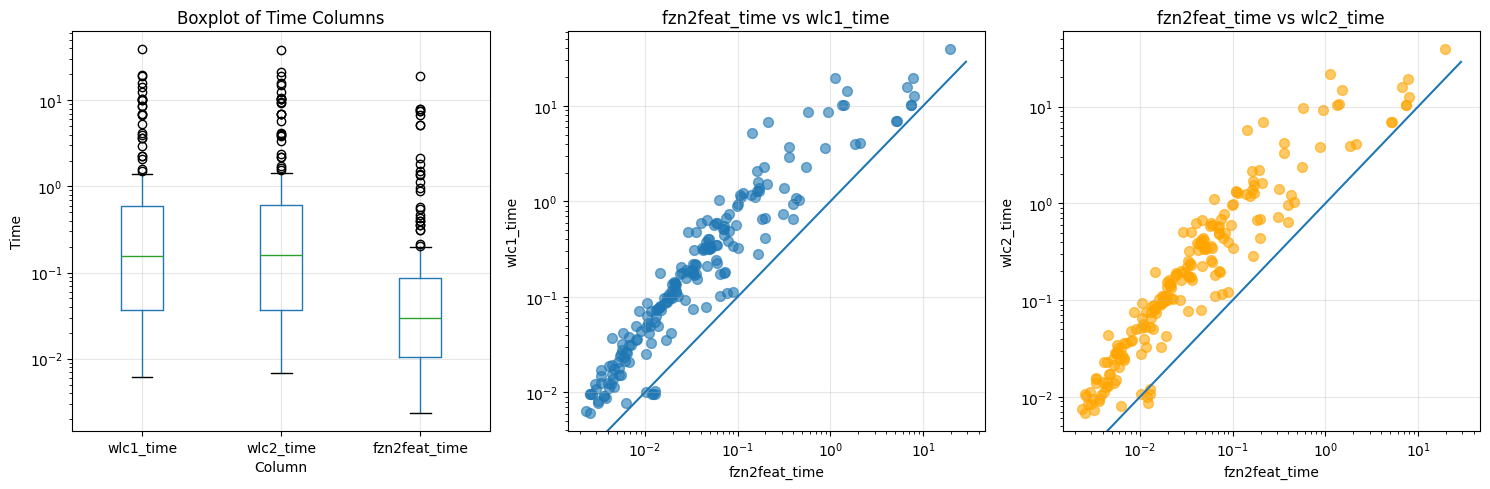

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Boxplot - each time column as a separate box
time_columns = ['wlc1_time', 'wlc2_time', 'fzn2feat_time']
merged[time_columns].boxplot(ax=axes[0])
axes[0].set_title('Boxplot of Time Columns')
axes[0].set_ylabel('Time')
axes[0].set_xlabel('Column')
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# 2. First scatter plot: fzn2feat_time vs wlc1_time
axes[1].scatter(merged['fzn2feat_time'], merged['wlc1_time'], alpha=0.6, s=50)
axes[1].plot([i for i in range(30)], [i for i in range(30)])
axes[1].set_xlabel('fzn2feat_time')
axes[1].set_ylabel('wlc1_time')
axes[1].set_title('fzn2feat_time vs wlc1_time')
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')
axes[1].set_xscale('log')


# 3. Second scatter plot: fzn2feat_time vs wlc2_time
axes[2].scatter(merged['fzn2feat_time'], merged['wlc2_time'], alpha=0.6, s=50, color='orange')
axes[2].plot([i for i in range(30)], [i for i in range(30)])
axes[2].set_xlabel('fzn2feat_time')
axes[2].set_ylabel('wlc2_time')
axes[2].set_title('fzn2feat_time vs wlc2_time')
axes[2].grid(True, alpha=0.3)
axes[2].set_yscale('log')
axes[2].set_xscale('log')

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plot
plt.show()

In [14]:
fzn2feat_result = {"accuracy": 0.7166666666666667, "hyperparameters": {"max_depth": 10, "max_features": "log2", "min_samples_leaf": 1, "min_samples_split": 2, "n_estimators": 200, "random_state": 42, "size": None}, "predictions": {"accap-sep-accap_a8_f50_t30": {"pred": 0, "true": 1}, "efm_cstr-sep-MODEL2204150001": {"pred": 1, "true": 1}, "accap-sep-accap_a30_f300_t120": {"pred": 0, "true": 0}, "stripboard-sep-stripboard_w20_h15_l12_c6_n12": {"pred": 1, "true": 1}, "hitori-sep-h5-1": {"pred": 1, "true": 0}, "wcsp-sep-1UBI.13p.9aa.usingEref_self_x": {"pred": 1, "true": 1}, "concert-hall-cap-sep-concert_100_20": {"pred": 0, "true": 0}, "hitori-sep-h11-1": {"pred": 1, "true": 0}, "product-and-shelves-sep-ps-25-01": {"pred": 0, "true": 1}, "neighbours-rect-sep-neightbours-new-7": {"pred": 1, "true": 1}, "peaceable_queens_mznc2021-sep-pq_n9": {"pred": 1, "true": 0}, "triangular-sep-n11": {"pred": 0, "true": 1}, "model4_opt-sep-i07": {"pred": 0, "true": 0}, "mondoku-gcc-model-balance-sep-12-12-8": {"pred": 1, "true": 0}, "cc_base-sep-cc_rnd_4_4": {"pred": 1, "true": 0}, "FBD1-sep-FBDk09": {"pred": 1, "true": 1}, "is-sep-avdoaYnfXq": {"pred": 0, "true": 0}, "word-sep-equations_01_track_140-int": {"pred": 1, "true": 0}, "FBD1-sep-FBDk07": {"pred": 1, "true": 1}, "peaceable_queens_mznc2021-sep-pq_n35": {"pred": 1, "true": 0}, "group-sep-u15g5pref1": {"pred": 0, "true": 0}, "stripboard-sep-stripboard_w20_h15_l7_c6_n24": {"pred": 1, "true": 1}, "foxgeesecorn-sep-foxgeesecorn_61": {"pred": 1, "true": 1}, "atsp-sep-instance11_0p25": {"pred": 1, "true": 1}, "ctw-sep-A041": {"pred": 1, "true": 1}, "monitor_1id-sep-igp_weight_based_rocketfuel_rf6461_real_hard": {"pred": 0, "true": 0}, "aircraft-sep-B737NG-600-06-Anon": {"pred": 0, "true": 0}, "skill_allocation_only-sep-skill_allocation_mzn_5d_1": {"pred": 0, "true": 0}, "neighbours-rect-sep-neightbours-new-15": {"pred": 1, "true": 0}, "stripboard-sep-stripboard_w20_h15_l4_c4_n24": {"pred": 1, "true": 1}, "cgt-sep-cgt_3_h39_r0.05_s1_3": {"pred": 1, "true": 0}, "graph_clear_cp-sep-planar_n20_seed2022_15": {"pred": 1, "true": 1}, "cc_base-sep-cc_rnd_8_2": {"pred": 1, "true": 1}, "black-hole-sep-layout_27": {"pred": 0, "true": 0}, "hitori-sep-h20-2": {"pred": 0, "true": 1}, "gt-sort-sep-n9_ub10_50.0_BEST": {"pred": 1, "true": 1}, "tsptw-sep-n20w140.005": {"pred": 1, "true": 1}, "mondoku-gcc-model-balance-sep-8-8-4": {"pred": 1, "true": 0}, "work-task-variation-sep-generated-seed-10-length-12-open-10-workers-12-block-5": {"pred": 0, "true": 0}, "yumi-dynamic-sep-p_9_GSGS_GSGSG_yumi_grid_setup_7_7_zones": {"pred": 0, "true": 0}, "sudoku_fixed-sep-sudoku_p89": {"pred": 1, "true": 1}, "bool-model-sep-s200_e50_c8": {"pred": 0, "true": 0}, "handball-sep-handball8": {"pred": 0, "true": 0}, "yumi-static-sep-p_4_GG_GG_yumi_grid_setup_7_7": {"pred": 1, "true": 1}, "handball-sep-handball10": {"pred": 1, "true": 1}, "unison-sep-mips_gcc.flow.find_regno_partial": {"pred": 0, "true": 1}, "chessboard-sep-chessboard_n12_1": {"pred": 1, "true": 1}, "test-scheduling-sep-t100m20r3-14": {"pred": 1, "true": 0}, "ccmcp-sep-3_20_0.30_4": {"pred": 1, "true": 1}, "ccmcp-sep-3_25_0.10_2": {"pred": 1, "true": 1}, "unison-sep-mips_mesa.eval.gl_Map1f": {"pred": 0, "true": 0}, "gametes-sep-gamete_nl20_m30_778477": {"pred": 1, "true": 1}, "roster_model-sep-chicroster_dataset_9": {"pred": 0, "true": 0}, "vrplc_service-sep-vrplc11_5_15_s4": {"pred": 0, "true": 0}, "pennies-sep-n12": {"pred": 1, "true": 1}, "evmopt-generic-sep-Kongu_run_code_of_0_block_240_0_input": {"pred": 0, "true": 0}, "mrcpsp-sep-j30_29_3": {"pred": 1, "true": 1}, "graph-scan-revised-sep-rnd_n40_p1000_c20_s1": {"pred": 1, "true": 0}, "TableLayout-sep-p1000_m10_r200_c15": {"pred": 1, "true": 1}, "Unit-Commitment-sep-L15-T48G30L15": {"pred": 1, "true": 1}}}

In [15]:
hyperparameters = fzn2feat_result["hyperparameters"]
del hyperparameters["size"]

In [16]:
test_instances = set(fzn2feat_result['predictions'].keys())

In [17]:
dataset = pd.read_csv('data/parallelise_cplex.csv')
#e['model']}-sep-{e['name']}
dataset['prediction_name'] = dataset['model'] + '-sep-' + dataset['name']
train_data_df = dataset[~(dataset['prediction_name'].isin(test_instances))]
test_data_df = dataset[(dataset['prediction_name'].isin(test_instances))]

In [18]:
fzn2feat_features = pd.read_csv('data/fzn2feat_joined.csv')

In [19]:
train_data = []
for i in range(len(train_data_df)):
    line = train_data_df.iloc[i,:]
    f = fzn2feat_features[(fzn2feat_features['problem'] == line['model']) & (fzn2feat_features['name'] == line['name'])]
    f = f.drop(columns=['problem','name'])
    d = {'model': line['model'],
         'name': line['name'],
         'label': line['y'],
         'features': f.values[0]}
    train_data.append(d)

test_data = []
for i in range(len(test_data_df)):
    line = test_data_df.iloc[i,:]
    f = fzn2feat_features[(fzn2feat_features['problem'] == line['model']) & (fzn2feat_features['name'] == line['name'])]
    f = f.drop(columns=['problem','name'])
    d = {'model': line['model'],
         'name': line['name'],
         'label': line['y'],
         'features': f.values[0]}
    test_data.append(d)

In [20]:
X_train = np.array([e['features'] for e in train_data])
y_train = np.array([e['label'] for e in train_data])
X_test = np.array([e['features'] for e in test_data])
y_test = np.array([e['label'] for e in test_data])

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [22]:
clf = RandomForestClassifier(**hyperparameters)
clf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
accuracy_score(y_test, clf.predict(X_test)), accuracy_score(y_train, clf.predict(X_train))

(0.7166666666666667, 1.0)

In [179]:
np.argmax(clf.feature_importances_)

34

In [180]:
fzn2feat_features.columns.to_list()[34]

'd_int_cons'